In [1]:
import exo_k as xk
import matplotlib.pyplot as plt
from kamino.utils import august_roche_magnus_formula

In [2]:
xk.Settings().set_mks(True)

In [3]:
k_data_path = '../src/kamino/climate/data/data_tutorial_exo-k_interior/'
xk.Settings().set_search_path(k_data_path+'corrk', path_type='ktable')
xk.Settings().set_search_path(k_data_path+'cia', path_type='cia')

In [26]:
molecules = ['H2O', 'CO2']
k_db = xk.Kdatabase(molecules, search_path=k_data_path+'corrk/R2_homogeneous_from_R500', remove_zeros=True)
print(k_db)

cia_molecules = ['H2O_H2O']
cia_db = xk.CIAdatabase(cia_molecules, search_path=k_data_path+'cia')
cia_db.sample(wngrid=k_db.wns)
print(cia_db)

The available molecules are: 
H2O->../src/kamino/climate/data/data_tutorial_exo-k_interior/corrk/R2_homogeneous_from_R500/H2O.ktable.exorem.h5
CO2->../src/kamino/climate/data/data_tutorial_exo-k_interior/corrk/R2_homogeneous_from_R500/CO2.ktable.exorem.h5
All tables share a common spectral grid
All tables share a common logP-T grid
All tables share a common p unit
All tables share a common kdata unit

The available molecule pairs are: 
All tables share a common spectral grid



In [66]:
grav_earth = 9.81           # Surface gravity (m/s^2)
solar_constant = 1361.0     # Solar constant (W/m^2)
mean_insolation = 1.2 * solar_constant / 4.0 # Hemispherically averaged
surface_albedo = 0.12
bond_albedo = 0.3

In [88]:
august_roche_magnus_formula(383) / 1e5

1.4747716983662515

In [89]:
H2O_vmr = 1
CO2_vmr = 0.004

composition = {'N2': 'background', 'H2O': H2O_vmr, 'CO2': CO2_vmr}

In [86]:
print("Initializing Atmosphere...")
atm = xk.Atm_evolution(
    Nlay=50,                  # Number of vertical layers
    Tsurf=288.0,              # Initial surface temperature guess
    Tstrat=200.0,             # Initial stratosphere temperature guess
    psurf=100000.0,           # Surface pressure in Pa (1 bar)
    ptop=10.0,                # Top of atmosphere pressure (0.1 mbar)
    grav=grav_earth,          # Surface gravity
    albedo_surf=surface_albedo,
    rcp=0.28,                 # R/Cp for the gas mixture
    bg_vmr=composition,
    k_database=k_db,
    cia_database=None,        # Can be replaced with xk.CIAdatabase(...) if you have CIA tables
    internal_flux=0.0,        # No internal heat for an Earth-like rocky planet
    flux_top_dw=mean_insolation * (1.0 - bond_albedo), 
    verbose=True,
    rayleigh=True,            # Enable Rayleigh scattering
    convection=True,          # Enable convective adjustment
    acceleration_mode=4,      # Core tutorial setting for convergence speed
    dTmax_use_kernel=50.      # Core tutorial setting
)

Initializing Atmosphere...
cp, M_bg, rcp: 1511.9376252107202 0.02127868928 0.28
{'rayleigh': True, 'convection': True, 'convective_transport': True, 'diffusion': False, 'mix_potential_temp': False, 'molecular_diffusion': False, 'condensation': False, 'rain': False, 'latent_heating': True, 'moist_convection': False, 'moist_inhibition': False, 'surface_reservoir': False, 'mass_redistribution': False, 'compute_mass_fluxes': True, 'Kzz': 0.0, 'Kzz_pressure_factor': -1.0, 'Kzz_min': 0.0, 'dTmax_use_kernel': 50.0, 'evap_coeff': 1.0, 'acceleration_mode': 4, 'radiative_acceleration_factor': 1.0, 'convective_acceleration_factor': 1.0, 'condensation_timestep_reducer': 0.8, 'convective_acceleration_mode': 0, 'qcond_surf_layer': 0.1, 'q_cloud': 0.0, 'humidity_distribution_width': -1.0, 'acceleration_top_pressure': None, 'Nlay': 50, 'Tsurf': 288.0, 'Tstrat': 200.0, 'psurf': 100000.0, 'ptop': 10.0, 'grav': 9.81, 'albedo_surf': 0.12, 'rcp': 0.28, 'k_database': The available molecules are: 
H2O->../sr

In [90]:
print("Evolving the atmosphere towards Radiative-Convective Equilibrium...")
# equilibrate() automatically handles the timestep adjustment and kernel computation
atm.equilibrate(
    Fnet_tolerance=0.1,       # Target net flux tolerance in W/m^2
    N_timestep_ini=100,       # Initial batch of timesteps before kernel evaluation
    N_iter_max=20,            # Max kernel iterations
    N_timestep_max=40000,     # Max total timesteps
    verbose=True
)

print()
print(f'Surface Temperature: {atm.tlay[-1]:.1f} K')

Evolving the atmosphere towards Radiative-Convective Equilibrium...
iter: 1, N_timestep: 100
Fnet mean: -0.000443 W/m^2, (min:-0.00559, max:-3.15e-09)
timestep: 0.2 d | 1.73e+04 s, total time: 0.0548 yr

Surface Temperature: 383.1 K


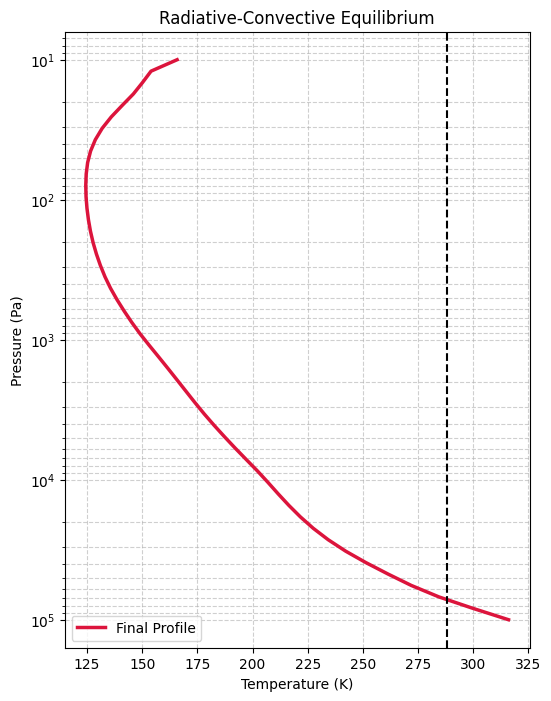

In [32]:
plt.figure(figsize=(6, 8))

# atm.atm.play = pressure at layer centers; atm.tlay = temp at layer centers
plt.plot(atm.tlay, atm.atm.play, color='crimson', linewidth=2.5, label='Final Profile')

# Standard meteorological convention: log scale for pressure, inverted axis
plt.yscale('log')
plt.gca().invert_yaxis()  

plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
plt.title('Radiative-Convective Equilibrium')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.axvline(288, color='black', linestyle='--')
plt.show()